In [10]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 4
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    num_quantiles       = 1,

    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,

    feature_popdens     = True,
    feature_gisd        = True
    )    


epidata_orchestrator  = (EpiDataOrchestrator(config)
                      .load_raw()
                      .harmonize_raw()
                      .process_data()
                      .build_features()
                      .normalize()
                      .finalize()
                      )

In [11]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager
baselinedata             = BaseLineDataLoaderManager(epidata_orchestrator)

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

graphdataloader_ig       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('identity_graph').build()
graphdataloader_gn       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('geographical_neighbors1').build()
# graphdataloader_cm11     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter14_1').build()
# graphdataloader_cm12     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter14_2').build()
# graphdataloader_cm13     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter14_3').build()
# graphdataloader_cm14     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter14_4').build()
graphdataloader_cm21     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_1').build()
# graphdataloader_cm22     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_2').build()
# graphdataloader_cm23     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_3').build()
# graphdataloader_cm24     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_4').build()

In [12]:
from src.models import SimpleGCNModel, GATv2LSTMModel, GCNLSTMModel

In [13]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedata)
persistence.forecast()

climateology = ClimateologyModel(baselinedata)
climateology.forecast()

climascale = ClimaScaleModel(baselinedata)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]


==                  gcnlstm-1                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.7840, val loss: 1.1678 ✓ (new best)
Epoch 002 train loss: 0.5693, val loss: 0.7374 ✓ (new best)
Epoch 003 train loss: 0.5890, val loss: 0.6704 ✓ (new best)
Epoch 004 train loss: 0.5581, val loss: 0.5779 ✓ (new best)
Epoch 005 train loss: 0.5178, val loss: 0.5529 ✓ (new best)
Epoch 006 train loss: 0.5285, val loss: 0.5071 ✓ (new best)
Epoch 007 train loss: 0.4926, val loss: 0.4540 ✓ (new best)
Epoch 008 train loss: 0.4925, val loss: 0.4900 (patience: 1/20)
Epoch 009 train loss: 0.4726, val loss: 0.4253 ✓ (new best)
Epoch 010 train loss: 0.4700, val loss: 0.4663 (patience: 1/20)
Epoch 011 train loss: 0.4660, val loss: 0.3946 ✓ (new best)
Epoch 012 train loss: 0.4468, val loss: 0.4418 (patience: 1/20)
Epoch 013 train loss: 0.4573, val loss: 0.3865 ✓ (new best)
Epoch 014 train 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


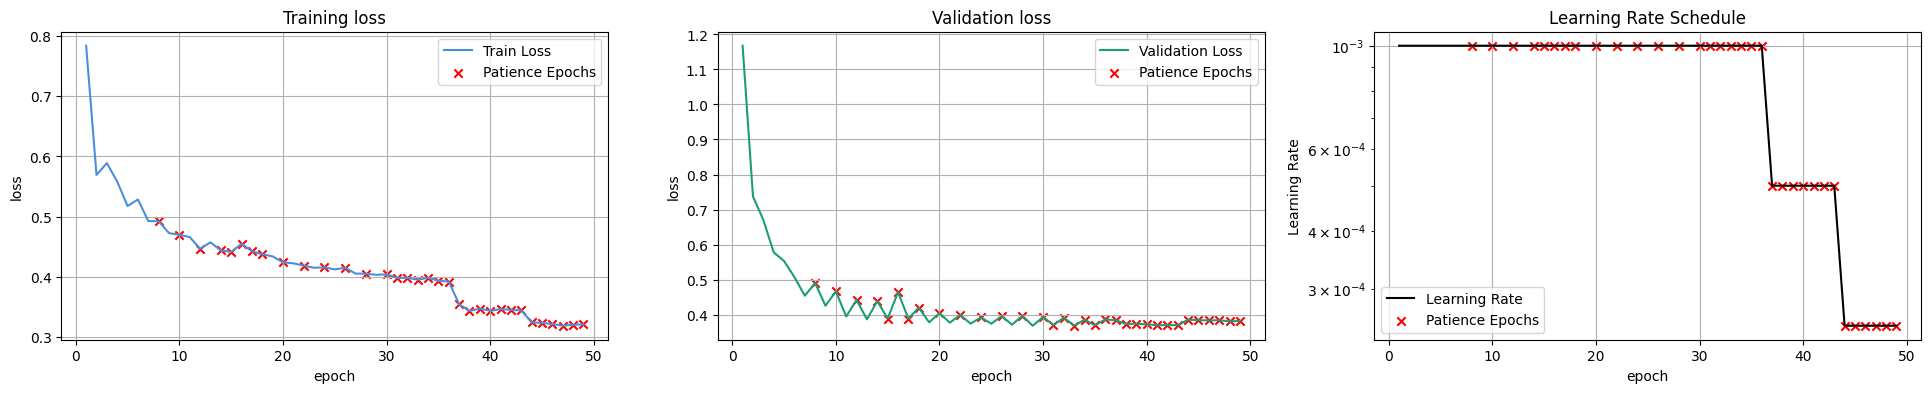

In [21]:
n_epochs        = 100
lr              = 0.001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

ml1 = GCNLSTMModel(graphdataloader_ig, name = 'gcnlstm-1',verbose = 2)
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train()


==                  gcnlstm-2                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.8727, val loss: 1.6817 ✓ (new best)
Epoch 002 train loss: 0.6898, val loss: 0.8473 ✓ (new best)
Epoch 003 train loss: 0.6221, val loss: 0.7165 ✓ (new best)
Epoch 004 train loss: 0.5561, val loss: 0.6231 ✓ (new best)
Epoch 005 train loss: 0.5546, val loss: 0.6582 (patience: 1/20)
Epoch 006 train loss: 0.5567, val loss: 0.5327 ✓ (new best)
Epoch 007 train loss: 0.5181, val loss: 0.5249 ✓ (new best)
Epoch 008 train loss: 0.5083, val loss: 0.4733 ✓ (new best)
Epoch 009 train loss: 0.4958, val loss: 0.4343 ✓ (new best)
Epoch 010 train loss: 0.4919, val loss: 0.4643 (patience: 1/20)
Epoch 011 train loss: 0.4799, val loss: 0.4195 ✓ (new best)
Epoch 012 train loss: 0.4812, val loss: 0.4248 (patience: 1/20)
Epoch 013 train loss: 0.4791, val loss: 0.4081 ✓ (new best)
Epoch 014 trai

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


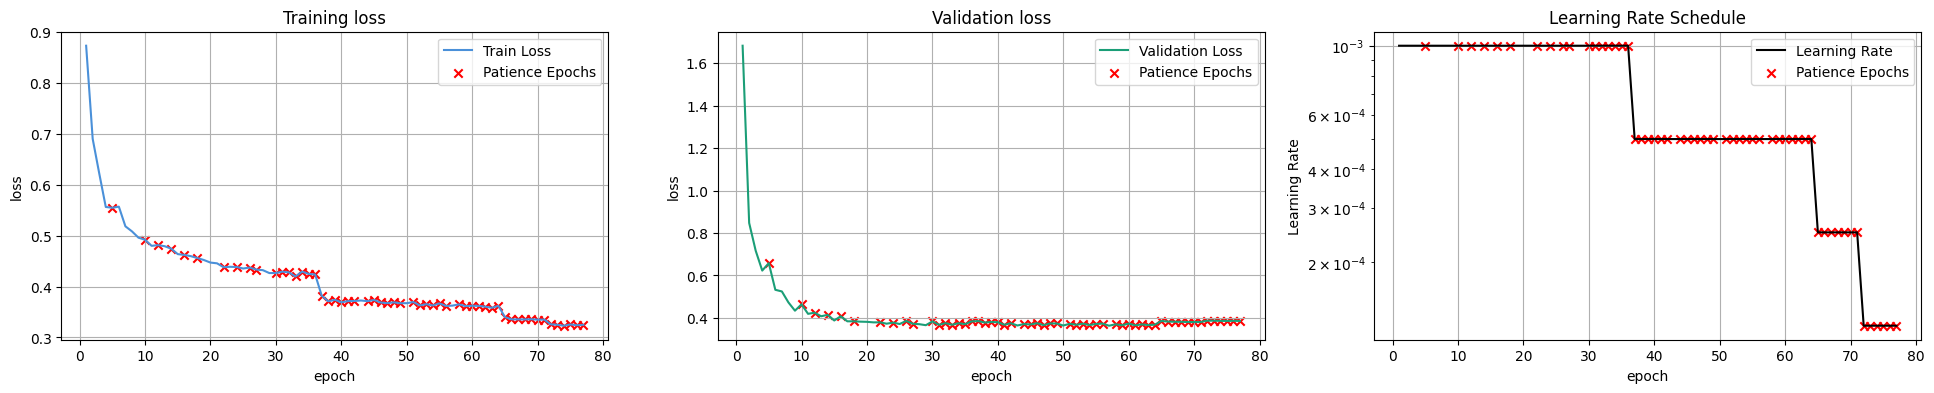

In [15]:

ml2 = GCNLSTMModel(graphdataloader_gn, name = 'gcnlstm-2',verbose = 2)
ml2.set_model_hparams()
ml2.set_global_hparams(**global_hparams)
ml2.train()


==                  gcnlstm-2                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 5, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.7480, val loss: 1.1171 ✓ (new best)
Epoch 002 train loss: 0.6229, val loss: 0.7022 ✓ (new best)
Epoch 003 train loss: 0.5489, val loss: 0.5524 ✓ (new best)
Epoch 004 train loss: 0.5291, val loss: 0.5881 (patience: 1/20)
Epoch 005 train loss: 0.5421, val loss: 0.5394 ✓ (new best)
Epoch 006 train loss: 0.4938, val loss: 0.5067 ✓ (new best)
Epoch 007 train loss: 0.4891, val loss: 0.4552 ✓ (new best)
Epoch 008 train loss: 0.4917, val loss: 0.4850 (patience: 1/20)
Epoch 009 train loss: 0.4888, val loss: 0.4541 ✓ (new best)
Epoch 010 train loss: 0.4809, val loss: 0.4433 ✓ (new best)
Epoch 011 train loss: 0.4811, val loss: 0.5336 (patience: 1/20)
Epoch 012 train loss: 0.4787, val loss: 0.4391 ✓ (new best)
Epoch 013 train loss: 0.4637, val loss: 0.4490 (patience: 1/20)
Epoch 014 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:241: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


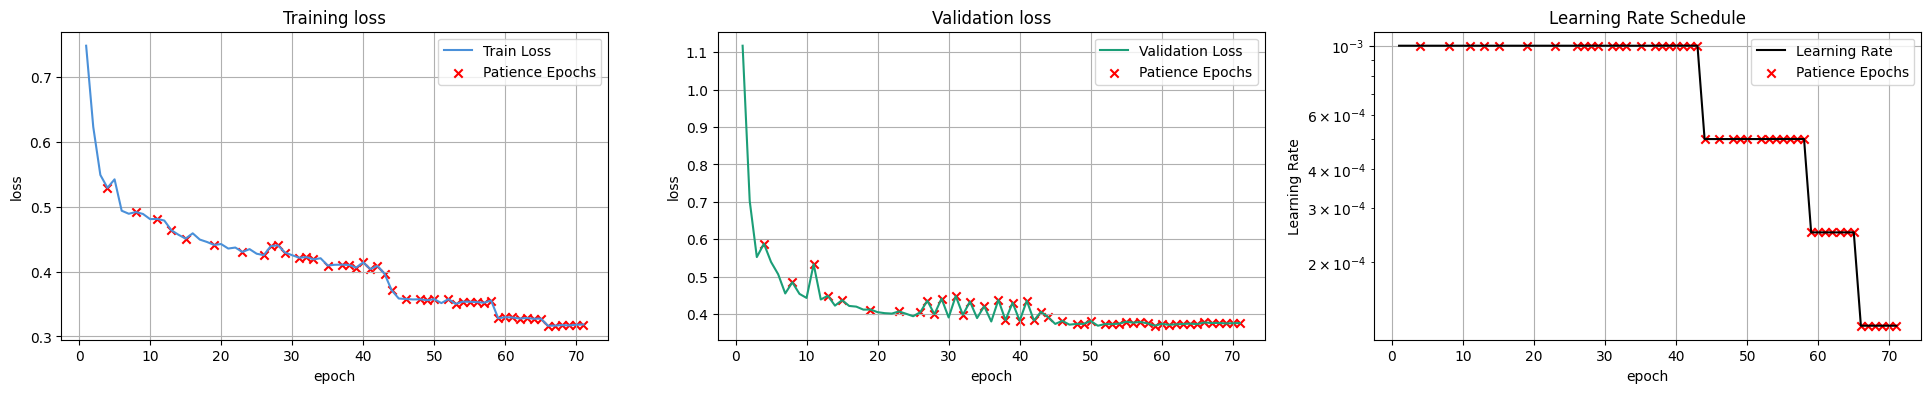

In [31]:

ml2 = GCNLSTMModel(graphdataloader_gn, name = 'gcnlstm-2',verbose = 2)
ml2.set_model_hparams(gcn_layers=2, lstm_hidden_size=32)
ml2.set_global_hparams(**global_hparams)
ml2.train()

Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 297.80it/s]


Test loss: 0.5208
forecasted ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 159.84it/s]


Test loss: 0.5237
forecasted ✓


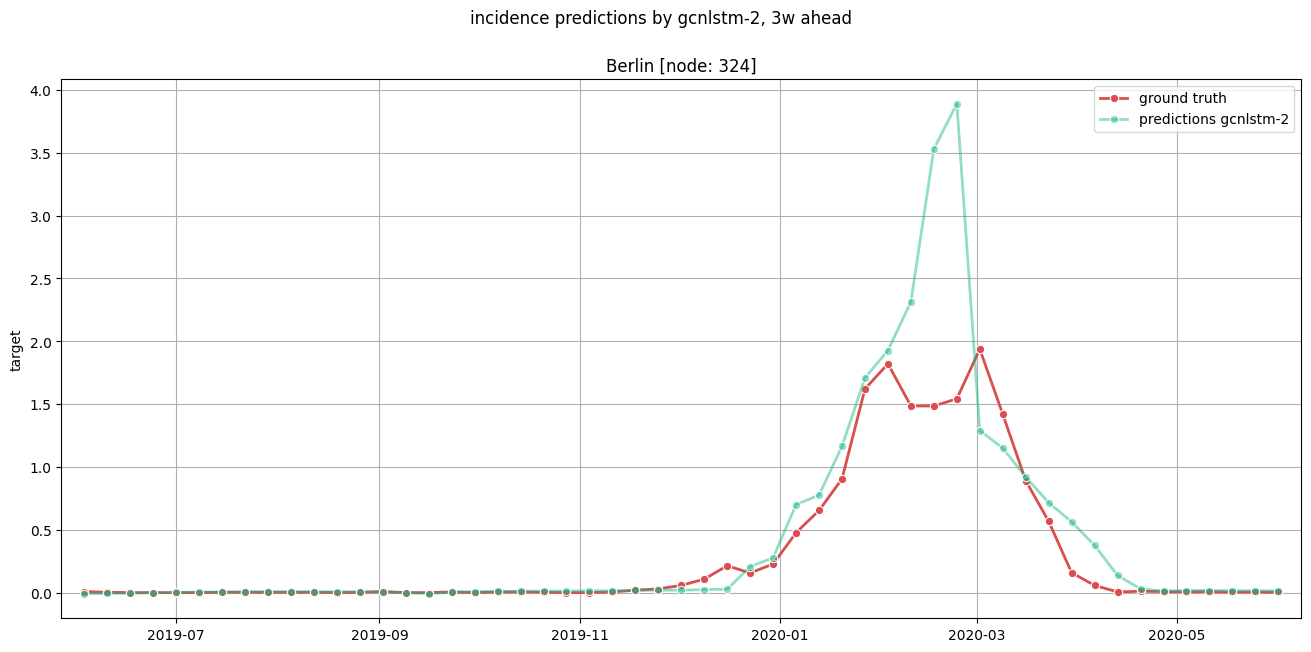

In [32]:
ml1.forecast()
ml1.show_forecasts(324).show()

ml2.forecast()
ml2.show_forecasts(324).show()

In [33]:
from src.evaluation import Evaluator

e = Evaluator(models = baseline_models + [ml1,ml2]).add_evaluation()


computing metrics:   0%|                                                                                                                                                                | 0/9 [00:00<?, ?it/s]

computing metrics:  89%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                 | 8/9 [00:06<00:00,  1.22it/s]/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58:

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplott

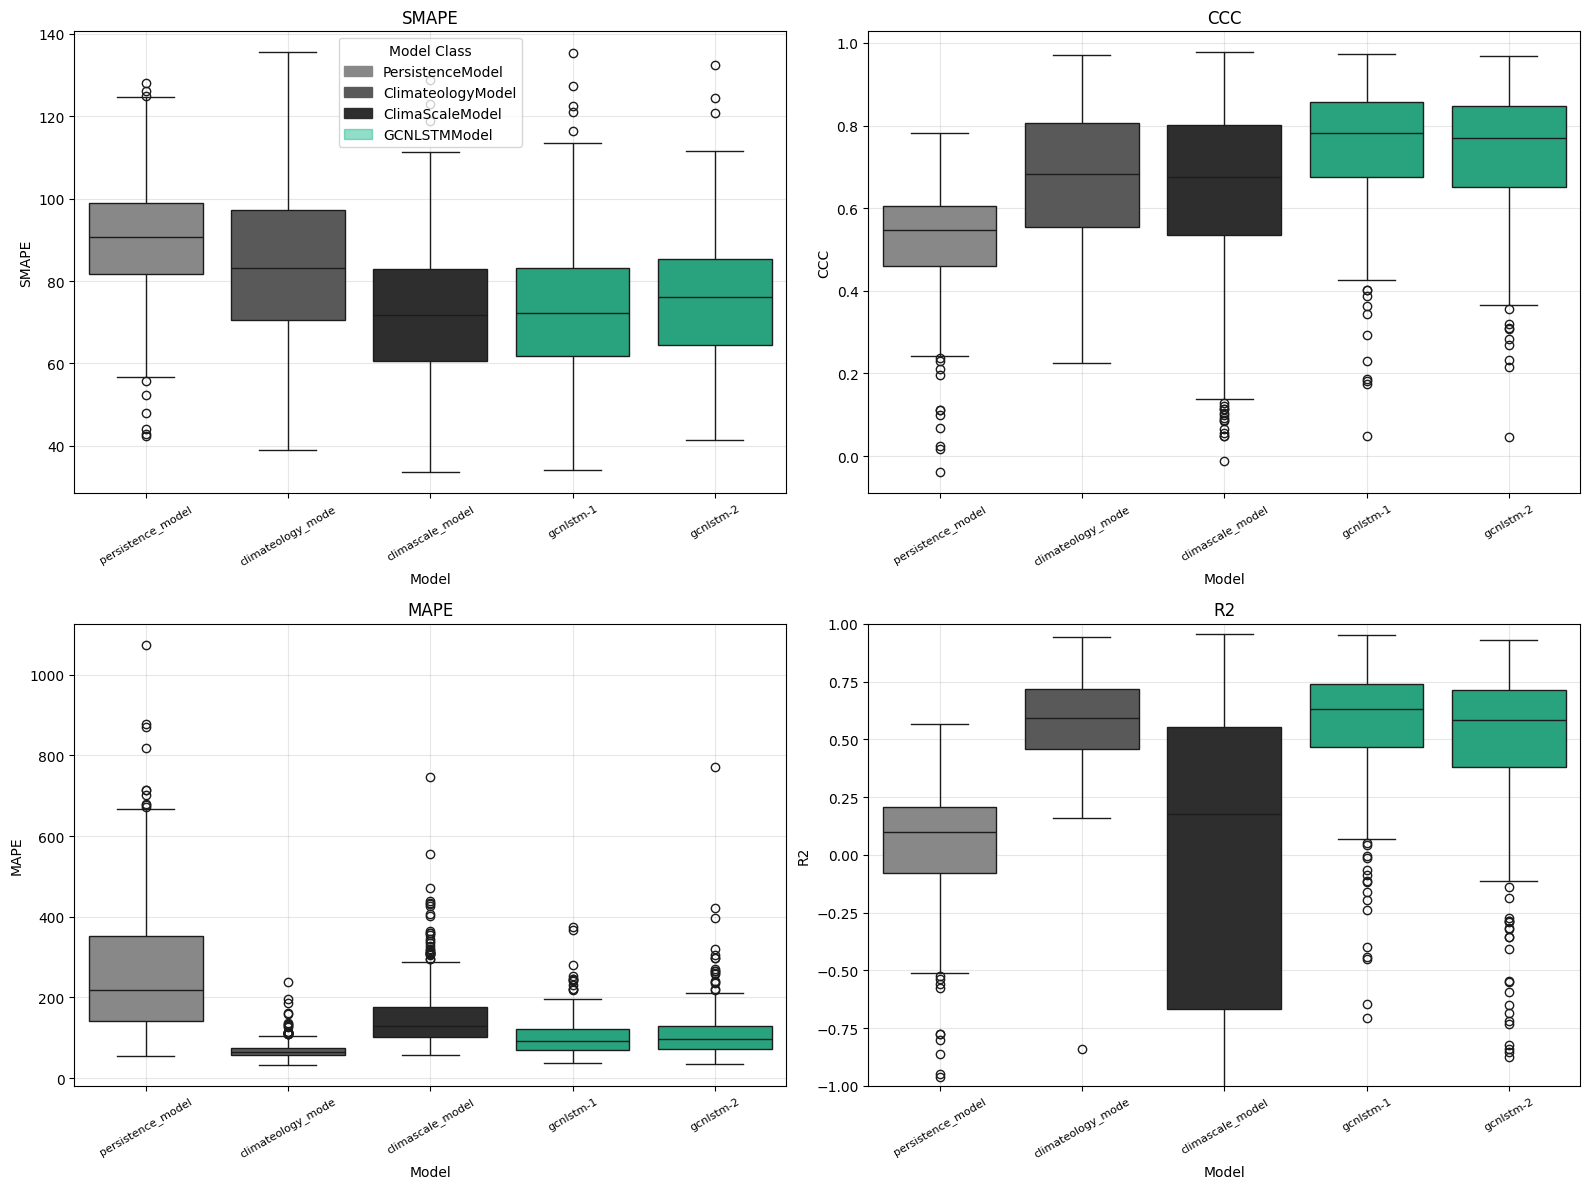

In [34]:
e.plotter.plot_metric_compilation(metrics = ['smape','ccc','mape','r2']).layout.set_ylim([-1,1], ax = 3).show()

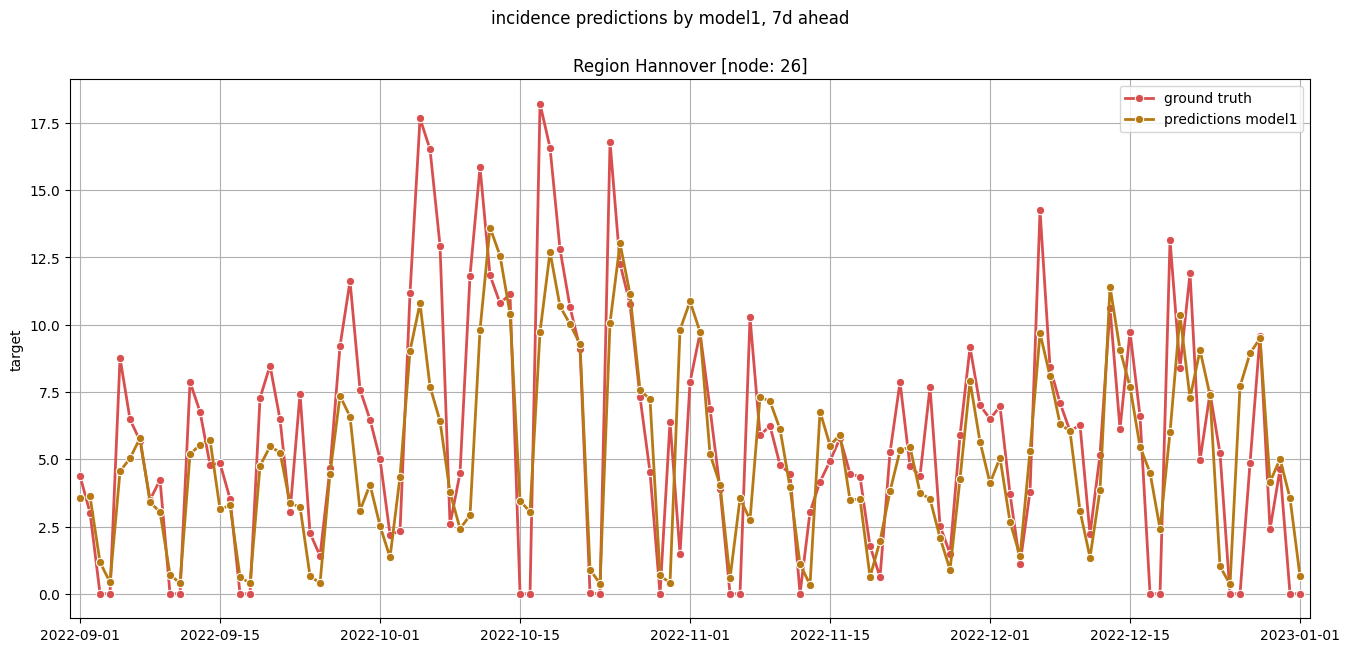

In [16]:
ml1.show_forecasts(26).show()

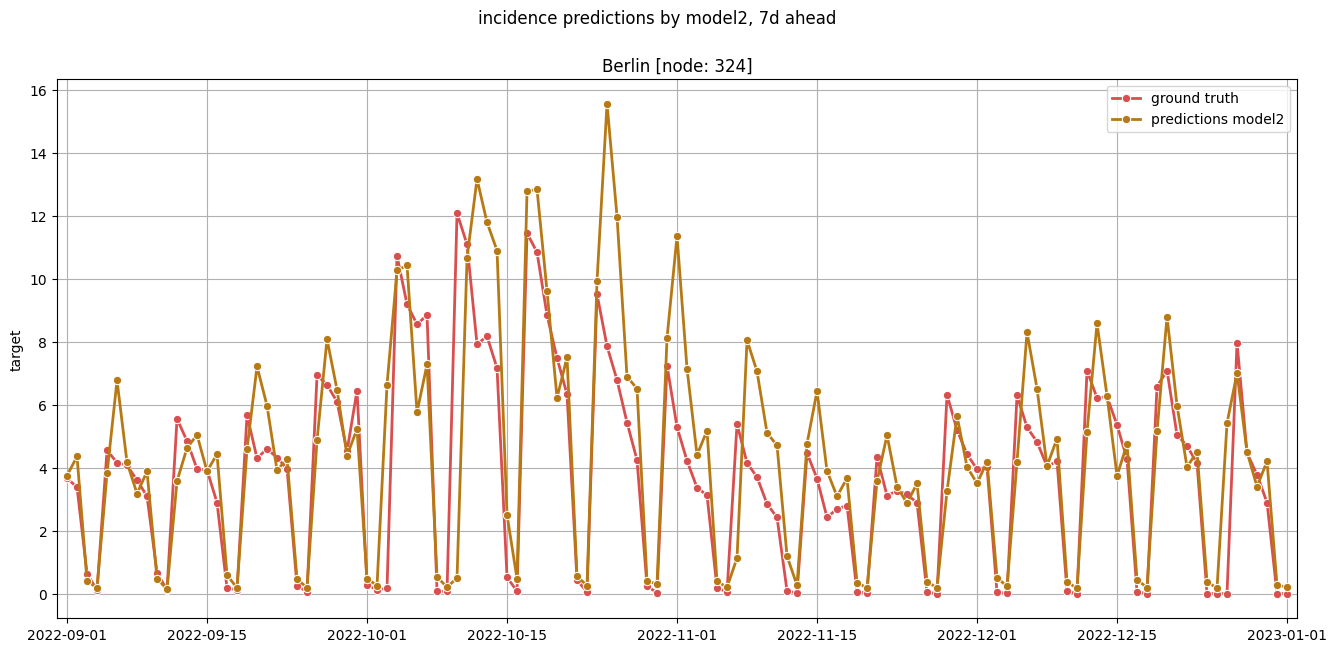

In [13]:
ml2.show_forecasts(324).show()

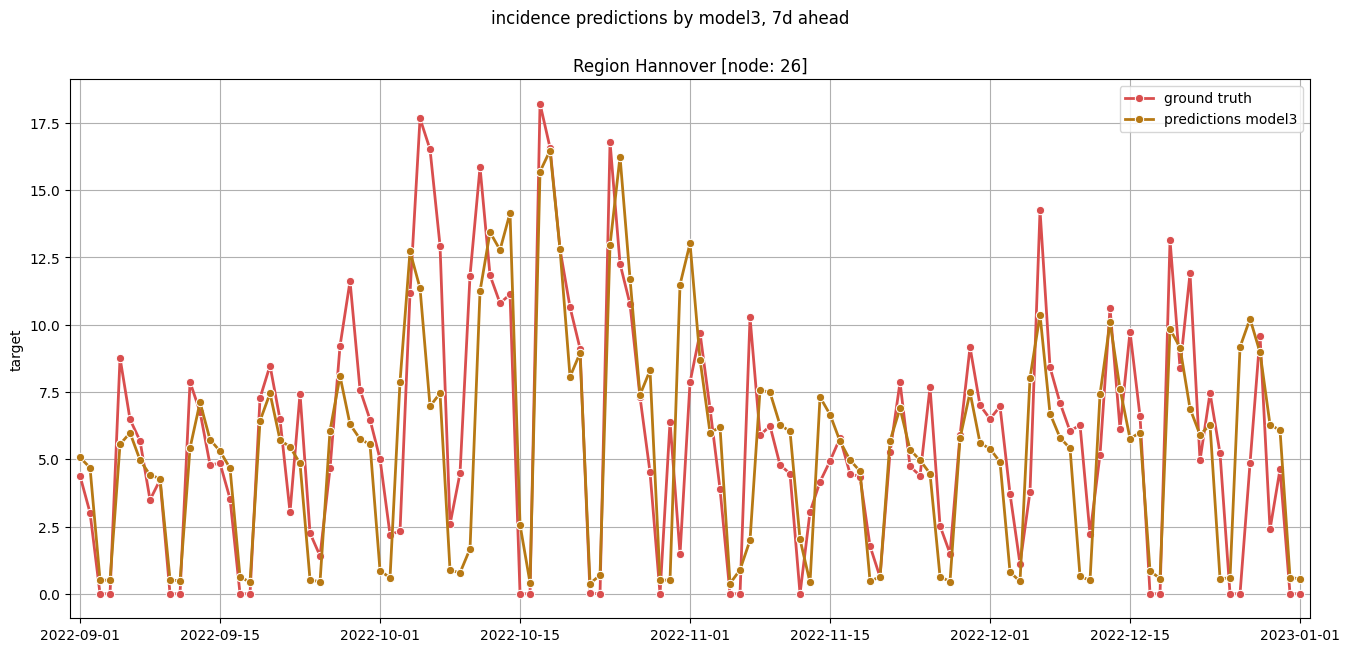

In [15]:
ml3.show_forecasts(26).show()